In [ ]:
modelos_candidatos = {
    'Regressao Logistica': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Arvore de Decisao': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric='logloss',
                               random_state=RANDOM_STATE,
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
    'Rede Neural (MLP)': MLPClassifier(hidden_layer_sizes=(32,16), max_iter=1000, random_state=RANDOM_STATE),
}

resultados = []
pipelines_treinados = {}

for nome, modelo in modelos_candidatos.items():
    pipe = Pipeline([('pre', cria_preprocessador()), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    resultados.append({
        'modelo': nome,
        'acuracia': accuracy_score(y_test, pred),
        'precisao': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })
    pipelines_treinados[nome] = pipe

res_df = pd.DataFrame(resultados).sort_values('roc_auc', ascending=False).reset_index(drop=True)
res_df


,modelo,acuracia,precisao,recall,f1,roc_auc
0,XGBoost,0.795164,0.844961,0.795620,0.819549,0.868671
1,Gradient Boosting,0.802276,0.811927,0.861314,0.835891,0.868280
2,Random Forest,0.761024,0.775510,0.832117,0.802817,0.843557
3,Árvore de Decisão,0.719772,0.838608,0.644769,0.729023,0.815343
4,Rede Neural (MLP),0.743954,0.775656,0.790754,0.783133,0.805228
5,Regressão Logística,0.687055,0.783383,0.642336,0.705882,0.754766


#Datathon Passos Mágicos — Fase 5 (POSTECH)
##Notebook 2 — Modelo Preditivo de Risco de Defasagem

Este notebook responde à **pergunta 9** do desafio:

> *Quais padrões nos indicadores permitem identificar alunos em risco antes
> de queda no desempenho ou aumento da defasagem? Construa um modelo
> preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de
> defasagem.*

**O que este notebook faz**, na ordem pedida pelo enunciado:
1. **Feature engineering** — construção e justificativa de cada variável usada;
2. **Separação treino/teste** — cuidando explicitamente de vazamento de dados (leakage);
3. **Modelagem preditiva** — comparação entre vários algoritmos (Machine Learning
   e uma rede neural), com justificativa de qual é o mais adequado;
4. **Avaliação dos resultados** — métricas, matriz de confusão, importância de features;
5. Exportação do modelo treinado (pipeline completo) para uso no **app Streamlit**.

Este notebook é **autossuficiente**: ele tenta carregar a base já tratada pelo
`1_analise_exploratoria_e_limpeza.ipynb` (`painel_tratado.csv`) e, se não
encontrar, refaz a limpeza sozinho a partir da planilha bruta — então dá pra
rodar mesmo que você só abra este notebook.

> Para o racional completo por trás de cada decisão de limpeza (por que a
> idade é recalculada, por que a coluna `Fase` de 2024 tem um bug, etc.), veja
> o Notebook 1 — aqui vamos direto ao ponto, focando na parte de modelagem.


##Como rodar este notebook no Google Colab

1. Use a mesma pasta do projeto no Google Drive do Notebook 1
   (`tech_challenge_5_datathon/data/`), com o arquivo
   `BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx` dentro.
2. Se você já rodou o Notebook 1, o arquivo `painel_tratado.csv` já deve estar
   lá também (mais rápido). Se não rodou, sem problema — este notebook refaz
   a limpeza sozinho.
3. Rode as células em ordem. Ao final, o modelo treinado é salvo em
   `modelo/pipeline_risco_defasagem.joblib` — esse arquivo é usado pelo
   `3_app_streamlit.py`.


In [ ]:
import os

#Ajustado para usar os arquivos carregados localmente no Colab
CAMINHO_PROJETO = '.'
CAMINHO_BASE = 'BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx'
CAMINHO_PAINEL_TRATADO = 'painel_tratado.csv'

#Criamos a pasta 'modelo' localmente para salvar o resultado final
if not os.path.exists('modelo'):
    os.makedirs('modelo')

CAMINHO_MODELO = './modelo/pipeline_risco_defasagem.joblib'

print(f'Configurado para usar arquivos locais:')
print(f'- Base Bruta: {CAMINHO_BASE}')
print(f'- Painel Tratado: {CAMINHO_PAINEL_TRATADO}')
print(f'- Destino do Modelo: {CAMINHO_MODELO}')

Configurado para usar arquivos locais:
- Base Bruta: BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx
- Painel Tratado: painel_tratado.csv
- Destino do Modelo: ./modelo/pipeline_risco_defasagem.joblib


In [ ]:
!pip install -q xgboost==3.4.1 imbalanced-learn==0.14.2 \
    "scikit-learn==1.8.0" "pandas==3.0.2" "numpy==2.4.4" "joblib==1.5.3"


> ⚠️ **Sobre a célula acima — leia antes de continuar:**
>
> O modelo treinado neste notebook é salvo em disco via `joblib` (dentro de
> um `Pipeline` do scikit-learn). Esse formato **não é estável entre versões**
> do scikit-learn — carregar um pipeline salvo pela versão 1.8.0 usando a
> versão 1.4.2, por exemplo, quebra com
> `ModuleNotFoundError: No module named '_loss'` (testamos e confirmamos esse
> erro na prática). Por isso, fixamos aqui as mesmas versões de
> `scikit-learn`, `pandas`, `numpy` e `joblib` que serão usadas depois no
> `requirements.txt` do app Streamlit — **em vez de confiar no que o Colab
> já vem com por padrão**, que muda com o tempo e pode ficar diferente do
> ambiente de deploy.
>
> **Se o Colab reclamar de alguma incompatibilidade após rodar esta célula**
> (ex.: erro estranho em uma biblioteca que já estava importada), vá em
> `Ambiente de execução > Reiniciar sessão` e rode as células novamente
> desde o início — isso garante que as versões novas sejam realmente
> carregadas (o Colab às vezes mantém em memória uma versão antiga já
> importada antes da instalação).


In [ ]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [ ]:
#Conferindo que as versões realmente ativas batem com o que fixamos acima —
#se este print mostrar algo diferente de sklearn 1.8.0 / pandas 3.0.2 /
#numpy 2.4.4, reinicie a sessão do Colab (Ambiente de execução > Reiniciar
#sessão) e rode todas as células de novo antes de continuar.
import sklearn
print('Python      :', __import__('sys').version.split()[0])
print('scikit-learn:', sklearn.__version__, '(esperado: 1.8.0)')
print('pandas      :', pd.__version__, '(esperado: 3.0.2)')
print('numpy       :', np.__version__, '(esperado: 2.4.4)')
print('joblib      :', joblib.__version__, '(esperado: 1.5.3)')


Python      : 3.13.15
scikit-learn: 1.8.0 (esperado: 1.8.0)
pandas      : 3.0.2 (esperado: 3.0.2)
numpy       : 2.4.4 (esperado: 2.4.4)
joblib      : 1.5.3 (esperado: 1.5.3)


---
#1. Preparação dos dados

Vamos tentar carregar a base já tratada. Se não existir, refazemos a limpeza
(versão condensada da lógica explicada em detalhe no Notebook 1).


In [ ]:
def constroi_painel_do_zero(caminho_base):
    #Reconstrói o painel longitudinal tratado a partir da planilha bruta.
    #Mesma lógica do Notebook 1, de forma condensada.
    xls = pd.ExcelFile(caminho_base)
    df22 = pd.read_excel(xls, sheet_name='PEDE2022')
    df23 = pd.read_excel(xls, sheet_name='PEDE2023')
    df24 = pd.read_excel(xls, sheet_name='PEDE2024')

    MAPA_GENERO = {'Menina': 'Feminino', 'Menino': 'Masculino',
                   'Feminino': 'Feminino', 'Masculino': 'Masculino'}

    def padroniza_rede_ensino(v):
        if pd.isna(v):
            return 'Não informado'
        v = str(v)
        if 'Concluiu' in v or 'Formado' in v:
            return 'Concluinte'
        if 'Pública' in v or 'Publica' in v:
            return 'Pública'
        if 'Privada' in v:
            return 'Privada'
        if 'Decisão' in v or 'JP II' in v:
            return 'Privada'
        return 'Outro/Não informado'

    def padroniza_pedra(v):
        if pd.isna(v):
            return np.nan
        v = str(v).strip()
        if v in ('INCLUIR', ''):
            return np.nan
        v = v.replace('Á','A').replace('á','a').replace('Ó','O').replace('ó','o').capitalize()
        return v if v in ('Quartzo','Agata','Ametista','Topazio') else np.nan

    FASE_RE = re.compile(r'(ALFA|Fase\s*(\d))', re.IGNORECASE)
    def extrai_fase_numero(t):
        if pd.isna(t):
            return np.nan
        m = FASE_RE.search(str(t))
        if not m:
            return np.nan
        return 0 if m.group(1).upper().startswith('ALFA') else int(m.group(2))

    def extrai_fase_da_turma(turma):
        if pd.isna(turma):
            return np.nan
        t = str(turma).strip().upper()
        if t.startswith('ALFA'):
            return 0
        m = re.match(r'^(\d)', t)
        return int(m.group(1)) if m else np.nan

    def extrai_ano_nascimento(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, str):
            d = pd.to_datetime(v, errors='coerce')
            return d.year if pd.notna(d) else np.nan
        if hasattr(v, 'year'):
            return v.year
        return np.nan

    a = pd.DataFrame()
    a['RA'] = df22['RA']; a['ano_pesquisa'] = 2022
    a['fase'] = df22['Fase']; a['fase_ideal'] = df22['Fase ideal'].apply(extrai_fase_numero)
    a['defasagem'] = df22['Defas']; a['turma'] = df22['Turma']
    a['genero'] = df22['Gênero'].map(MAPA_GENERO)
    a['ano_nascimento'] = df22['Ano nasc']; a['idade'] = df22['Idade 22']
    a['ano_ingresso'] = df22['Ano ingresso']
    a['rede_ensino'] = df22['Instituição de ensino'].apply(padroniza_rede_ensino)
    a['pedra_atual'] = df22['Pedra 22'].apply(padroniza_pedra)
    a['pedra_ano_anterior'] = df22['Pedra 21'].apply(padroniza_pedra)
    a['inde'] = df22['INDE 22']; a['inde_ano_anterior'] = np.nan
    a['iaa'] = df22['IAA']; a['ieg'] = df22['IEG']; a['ips'] = df22['IPS']; a['ipp'] = np.nan
    a['ida'] = df22['IDA']; a['ipv'] = df22['IPV']; a['ian'] = df22['IAN']
    a['n_avaliacoes'] = df22['Nº Av']

    b = pd.DataFrame()
    b['RA'] = df23['RA']; b['ano_pesquisa'] = 2023
    b['fase'] = df23['Fase'].apply(lambda x: 0 if str(x).upper()=='ALFA' else int(re.search(r'\d+', str(x)).group()))
    b['fase_ideal'] = df23['Fase Ideal'].apply(extrai_fase_numero)
    b['defasagem'] = df23['Defasagem']; b['turma'] = df23['Turma']
    b['genero'] = df23['Gênero'].map(MAPA_GENERO)
    b['ano_nascimento'] = df23['Data de Nasc'].apply(extrai_ano_nascimento)
    b['idade'] = 2023 - b['ano_nascimento']; b['ano_ingresso'] = df23['Ano ingresso']
    b['rede_ensino'] = df23['Instituição de ensino'].apply(padroniza_rede_ensino)
    b['pedra_atual'] = df23['Pedra 2023'].apply(padroniza_pedra)
    b['pedra_ano_anterior'] = df23['Pedra 22'].apply(padroniza_pedra)
    b['inde'] = df23['INDE 2023']; b['inde_ano_anterior'] = df23['INDE 22']
    b['iaa'] = df23['IAA']; b['ieg'] = df23['IEG']; b['ips'] = df23['IPS']; b['ipp'] = df23['IPP']
    b['ida'] = df23['IDA']; b['ipv'] = df23['IPV']; b['ian'] = df23['IAN']
    b['n_avaliacoes'] = df23['Nº Av']

    c = pd.DataFrame()
    c['RA'] = df24['RA']; c['ano_pesquisa'] = 2024
    c['fase'] = df24['Turma'].apply(extrai_fase_da_turma)
    c['fase_ideal'] = df24['Fase Ideal'].apply(extrai_fase_numero)
    c['defasagem'] = df24['Defasagem']; c['turma'] = df24['Turma']
    c['genero'] = df24['Gênero'].map(MAPA_GENERO)
    c['ano_nascimento'] = df24['Data de Nasc'].apply(extrai_ano_nascimento)
    c['idade'] = 2024 - c['ano_nascimento']; c['ano_ingresso'] = df24['Ano ingresso']
    c['rede_ensino'] = df24['Instituição de ensino'].apply(padroniza_rede_ensino)
    c['pedra_atual'] = df24['Pedra 2024'].apply(padroniza_pedra)
    c['pedra_ano_anterior'] = df24['Pedra 23'].apply(padroniza_pedra)
    c['inde'] = pd.to_numeric(df24['INDE 2024'], errors='coerce'); c['inde_ano_anterior'] = df24['INDE 23']
    c['iaa'] = df24['IAA']; c['ieg'] = df24['IEG']; c['ips'] = df24['IPS']; c['ipp'] = df24['IPP']
    c['ida'] = df24['IDA']; c['ipv'] = df24['IPV']; c['ian'] = df24['IAN']
    c['n_avaliacoes'] = df24['Nº Av']

    painel = pd.concat([a, b, c], ignore_index=True)
    painel['tempo_na_associacao'] = painel['ano_pesquisa'] - painel['ano_ingresso']
    painel.loc[painel['tempo_na_associacao'] < 0, 'tempo_na_associacao'] = np.nan
    painel = painel[painel['rede_ensino'] != 'Concluinte'].copy()
    return painel


if os.path.exists(CAMINHO_PAINEL_TRATADO):
    print('Encontrei painel_tratado.csv (gerado pelo Notebook 1) — carregando direto.')
    painel = pd.read_csv(CAMINHO_PAINEL_TRATADO)
else:
    print('painel_tratado.csv nao encontrado — reconstruindo a partir da planilha bruta...')
    painel = constroi_painel_do_zero(CAMINHO_BASE)

print('Shape do painel:', painel.shape)
painel.head()


Encontrei painel_tratado.csv (gerado pelo Notebook 1) — carregando direto.
Shape do painel: (3003, 27)


,RA,ano_pesquisa,fase,fase_ideal,defasagem,turma,genero,ano_nascimento,idade,ano_ingresso,rede_ensino,pedra_atual,pedra_ano_anterior,inde,inde_ano_anterior,iaa,ieg,ips,ipp,ida,ipv,ian,n_avaliacoes,indicado_bolsa,atingiu_pv,tempo_na_associacao,categoria_defasagem
0,RA-1,2022,7,8,-1,A,Feminino,2003,19,2016,Pública,Quartzo,Ametista,5.783,NaN,8.3,4.1,5.6,NaN,4.0,7.278,5.0,4.0,Sim,Não,6.0,Moderada
1,RA-2,2022,7,7,0,A,Feminino,2005,17,2017,Privada,Ametista,Ametista,7.055,NaN,8.8,5.2,6.3,NaN,6.8,6.778,10.0,4.0,Não,Não,5.0,Em fase
2,RA-3,2022,7,7,0,A,Feminino,2005,17,2016,Privada,Agata,Ametista,6.591,NaN,0.0,7.9,5.6,NaN,5.6,7.556,10.0,4.0,Não,Não,6.0,Em fase
3,RA-4,2022,7,7,0,A,Masculino,2005,17,2017,Privada,Quartzo,Ametista,5.951,NaN,8.8,4.5,5.6,NaN,5.0,5.278,10.0,4.0,Não,Não,5.0,Em fase
4,RA-5,2022,7,7,0,A,Feminino,2005,17,2016,Privada,Ametista,Ametista,7.427,NaN,7.9,8.6,5.6,NaN,5.2,7.389,10.0,4.0,Não,Não,6.0,Em fase


---
#2. Feature Engineering

##2.1 — Definindo o alvo (target)

O alvo é **`risco_defasagem`**: 1 se o aluno está abaixo da fase ideal
(`defasagem < 0`), 0 caso contrário. Essa definição usa exatamente a mesma
regra que a Passos Mágicos usa para classificar o IAN como "Moderada"/"Severa"
(D < 0) versus "Em fase" (D ≥ 0) — ou seja, não estamos inventando um corte
arbitrário, estamos alinhados com o critério que a própria organização já usa.


In [ ]:
painel['risco_defasagem'] = (painel['defasagem'] < 0).astype(int)
print(painel['risco_defasagem'].value_counts(normalize=True).round(3))
print(painel['risco_defasagem'].value_counts())


risco_defasagem
1    0.558
0    0.442
Name: proportion, dtype: float64
risco_defasagem
1    1677
0    1326
Name: count, dtype: int64


O alvo está razoavelmente balanceado (~56% risco / ~44% sem risco) —
o que é bom, porque significa que não vamos precisar de técnicas agressivas
de balanceamento para o modelo aprender ambas as classes.

##2.2 — Por que **não** usar `IAN`, `Fase`, `Fase Ideal` ou `Defasagem` como feature

Óbvio, mas vale dizer explicitamente: essas colunas **são o alvo** (ou
derivam matematicamente dele). Usá-las como feature daria um modelo com
~100% de acurácia e zero utilidade prática — é o mesmo problema de vazamento
de dados identificado no Notebook 1 para o INDE.

##2.3 — Por que **também não** usar `INDE` ou `Pedra` como feature diretamente

O INDE inclui o IAN na sua fórmula (peso de 10%). Ainda que o peso seja baixo,
usar o INDE do **mesmo ano** do alvo deixaria vazar uma fração da informação
de defasagem para dentro do modelo. Por isso, o INDE do ano corrente também
fica de fora — mas o **INDE do ano anterior** (`inde_ano_anterior`) é uma
feature legítima e foi mantido: é uma informação de um período passado,
plenamente disponível no momento da previsão, e não é derivado do alvo do
período atual.

##2.4 — As features escolhidas


In [ ]:
ORDEM_PEDRA = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

#Pedra do ano anterior como variável ordinal (mais alta = melhor)
painel['pedra_ano_anterior_ord'] = painel['pedra_ano_anterior'].apply(
    lambda x: ORDEM_PEDRA.index(x) if x in ORDEM_PEDRA else -1)

#Flags de "informação disponível" — em vez de simplesmente imputar sem
#contexto, deixamos o modelo saber quando um dado é estruturalmente ausente
#(ex.: IPP não existia em 2022) versus um valor real
painel['tem_historico_pedra'] = painel['pedra_ano_anterior'].notna().astype(int)
painel['tem_ipp'] = painel['ipp'].notna().astype(int)
painel['tem_inde_anterior'] = painel['inde_ano_anterior'].notna().astype(int)

FEATURES_NUM = ['iaa', 'ieg', 'ips', 'ipp', 'ida', 'ipv', 'idade',
                'tempo_na_associacao', 'n_avaliacoes', 'inde_ano_anterior',
                'pedra_ano_anterior_ord']
FEATURES_FLAG = ['tem_historico_pedra', 'tem_ipp', 'tem_inde_anterior']
FEATURES_CAT = ['genero', 'rede_ensino']
TARGET = 'risco_defasagem'
GROUP = 'RA'

print('Features numericas :', FEATURES_NUM)
print('Features de flag    :', FEATURES_FLAG)
print('Features categoricas:', FEATURES_CAT)


Features numéricas : ['iaa', 'ieg', 'ips', 'ipp', 'ida', 'ipv', 'idade', 'tempo_na_associacao', 'n_avaliacoes', 'inde_ano_anterior', 'pedra_ano_anterior_ord']
Features de flag    : ['tem_historico_pedra', 'tem_ipp', 'tem_inde_anterior']
Features categóricas: ['genero', 'rede_ensino']


| Grupo | Feature | Por que faz sentido |
|---|---|---|
| Acadêmico/comportamental | `iaa`, `ieg`, `ips`, `ipp`, `ida`, `ipv` | As 6 dimensões do INDE que **não** são o IAN — captam desempenho, engajamento, psicossocial, psicopedagógico e ponto de virada, sem vazar o alvo |
| Demografia | `idade`, `genero` | Perfil do aluno |
| Histórico na associação | `tempo_na_associacao` | Alunos mais/menos recentes podem ter dinâmicas diferentes de adaptação |
| Contexto escolar | `rede_ensino` | Achamos no Notebook 1 (pergunta 11) que é o fator com maior diferença de risco observada |
| Tendência | `inde_ano_anterior`, `pedra_ano_anterior_ord` | Desempenho passado é, em geral, um dos melhores preditores de desempenho futuro — e não vaza o alvo do ano atual |
| Qualidade do dado | `n_avaliacoes`, `tem_*` | Quantidade de avaliações e "de onde vem" cada dado ausente também carregam sinal |

##2.5 — Filtrando linhas sem indicadores essenciais

Um aluno sem `iaa`, `ieg`, `ips`, `ida` ou `ipv` preenchidos não tem
informação suficiente para o modelo aprender nada — melhor excluir essas
linhas do treino/teste do que forçar uma imputação sobre um registro quase
vazio.


In [ ]:
cols_necessarias = FEATURES_NUM + FEATURES_FLAG + FEATURES_CAT + [TARGET, GROUP]
d = painel[cols_necessarias].copy()
print('Linhas antes do filtro:', len(d))

d = d.dropna(subset=['iaa', 'ieg', 'ips', 'ida', 'ipv'])
print('Linhas depois do filtro (indicadores essenciais presentes):', len(d))

print('% de nulos remanescentes por coluna (serao tratados no pipeline, com imputacao FIT SO NO TREINO):')
print((d[FEATURES_NUM].isna().mean()*100).round(1))


Linhas antes do filtro: 3003
Linhas depois do filtro (indicadores essenciais presentes): 2835

% de nulos remanescentes por coluna (serão tratados no pipeline, com imputação FIT SÓ NO TREINO):
iaa                        0.0
ieg                        0.0
ips                        0.0
ipp                       30.3
ida                        0.0
ipv                        0.0
idade                      0.0
tempo_na_associacao        0.0
n_avaliacoes               0.0
inde_ano_anterior         56.2
pedra_ano_anterior_ord     0.0
dtype: float64


---
#3. Separação treino/teste — cuidando do vazamento de dados

##3.1 — Por que não pode ser um split aleatório simples de linhas

Como o mesmo aluno (`RA`) pode aparecer em **até 3 linhas** (uma por ano),
um `train_test_split` comum poderia colocar o registro de 2022 de um aluno no
treino e o registro de 2023 **do mesmo aluno** no teste. O modelo "veria" esse
aluno durante o treino (ainda que em outro ano) e teria vantagem artificial
na hora de prever o registro de teste — um vazamento sutil, mas real.

**Solução:** usar `GroupShuffleSplit`, agrupando por `RA`, garantindo que
**todas** as linhas de um mesmo aluno fiquem inteiramente no treino OU
inteiramente no teste, nunca nos dois.

##3.2 — Por que os tratamentos (imputação, padronização, one-hot) são feitos
DEPOIS do split, dentro de um `Pipeline`

Se calcularmos a média para imputação, ou ajustarmos o `StandardScaler`, usando
a base inteira (treino + teste) **antes** de separar, o teste "vaza"
informação estatística para o treino (o modelo indiretamente "vê" a
distribuição dos dados de teste). O jeito certo é: **fit** do
imputer/scaler/encoder **só no treino**, e depois aplicar (`transform`) esse
mesmo ajuste no teste. Usar um `sklearn.Pipeline` + `ColumnTransformer` faz
isso automaticamente e de forma segura — inclusive dentro da validação
cruzada.


In [ ]:
X = d[FEATURES_NUM + FEATURES_FLAG + FEATURES_CAT]
y = d[TARGET]
groups = d[GROUP]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f'Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros')
print(f'Balanceamento do alvo — treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}')

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f'Alunos (RA) presentes em treino E teste ao mesmo tempo: {len(overlap)}  <- tem que ser 0')


Treino: 2132 registros | Teste: 703 registros
Balanceamento do alvo — treino: 59.1% | teste: 58.5%
Alunos (RA) presentes em treino E teste ao mesmo tempo: 0  <- tem que ser 0


##3.3 — O pipeline de pre-processamento

Definimos como uma **função-fábrica** (`cria_preprocessador()`), para poder
gerar uma instância nova e "limpa" para cada modelo testado — evita qualquer
dúvida sobre estado compartilhado entre os testes.


In [ ]:
def cria_preprocessador():
    return ColumnTransformer([
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  #mediana é robusta a outliers
            ('scaler', StandardScaler()),                     #necessário para Regressão Logística e MLP
        ]), FEATURES_NUM),
        ('flags', 'passthrough', FEATURES_FLAG),
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), FEATURES_CAT),
    ])

print('Funcao de pre-processamento definida.')


Função de pré-processamento definida.


---
#4. Balanceamento de classes

O alvo está em ~56%/44% — não é um desbalanceamento severo (problemas sérios
de desbalanceamento costumam aparecer quando a classe minoritária fica abaixo
de ~20-30%). Ainda assim, vamos tratar isso explicitamente de duas formas, e
comparar:

1. **`class_weight='balanced'`** — ajusta o peso do erro de cada classe
   automaticamente durante o treino, sem duplicar/inventar linhas. É a opção
   mais simples e, para um desbalanceamento leve como este, costuma ser
   suficiente.
2. **SMOTE** (Synthetic Minority Oversampling) — gera exemplos sintéticos da
   classe minoritária por interpolação. Mais indicado para desbalanceamentos
   fortes; aqui serve para comparação.

**Importante:** balanceamento (como qualquer tratamento) é aplicado **só no
treino**, nunca no teste — testar com dados sintéticos ou reponderados
daria uma estimativa de performance irreal.


In [ ]:
from imblearn.over_sampling import SMOTE

#Rápida comparação: Random Forest com class_weight='balanced' vs com SMOTE
pre_a = cria_preprocessador()
X_train_proc = pre_a.fit_transform(X_train, y_train)
X_test_proc = pre_a.transform(X_test)

rf_cw = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
rf_cw.fit(X_train_proc, y_train)
auc_cw = roc_auc_score(y_test, rf_cw.predict_proba(X_test_proc)[:,1])

sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train_proc, y_train)
rf_sm = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf_sm.fit(X_train_sm, y_train_sm)
auc_sm = roc_auc_score(y_test, rf_sm.predict_proba(X_test_proc)[:,1])

print(f'ROC-AUC com class_weight="balanced": {auc_cw:.4f}')
print(f'ROC-AUC com SMOTE                  : {auc_sm:.4f}')
print(f'Tamanho do treino original: {len(y_train)} | Tamanho do treino com SMOTE: {len(y_train_sm)}')


ROC-AUC com class_weight="balanced": 0.8436
ROC-AUC com SMOTE                  : 0.8380
Tamanho do treino original: 2132 | Tamanho do treino com SMOTE: 2518


**Decisão:** como esperado para um desbalanceamento leve, as duas
abordagens ficam muito próximas em performance. Vamos seguir com
**`class_weight='balanced'`** para o restante do notebook — é mais simples,
não infla artificialmente o tamanho do treino, e não exige carregar a
dependência `imbalanced-learn` no ambiente de produção (Streamlit Cloud).


---
#5. Modelagem preditiva: Machine Learning ou Deep Learning?

##Por que a expectativa, antes mesmo de rodar, é de que ML tradicional (árvores)
supere Deep Learning aqui

- **Volume de dados:** depois da limpeza, temos ~2.800 registros e ~15
  features. Redes neurais costumam precisar de ordens de grandeza a mais de
  dados para superar modelos baseados em árvore em problemas tabulares —
  esse é um resultado bem estabelecido na literatura de ML aplicado (não é
  uma opinião nossa, é um padrão bem documentado em benchmarks de dados
  tabulares).
- **Natureza dos dados:** são features numéricas/categóricas heterogêneas, com
  relações não necessariamente suaves — o ponto forte de modelos baseados em
  árvore (Random Forest, Gradient Boosting), que particionam o espaço de
  forma não-linear sem precisar de tanto dado para "aprender a forma" da
  relação.
- **Interpretabilidade:** a Passos Mágicos precisa **confiar** e **entender**
  por que um aluno foi sinalizado como risco (para a equipe pedagógica agir
  em cima disso). Árvores/Gradient Boosting têm importância de feature nativa
  e são mais fáceis de auditar do que uma rede neural.
- **Custo de operação:** o modelo final vai rodar em Streamlit Community
  Cloud (ambiente gratuito, recursos limitados) — um modelo de árvore é leve
  para treinar e para servir; redes neurais exigem mais ajuste de
  hiperparâmetros para não overfitar em bases pequenas.

Em vez de simplesmente assumir isso, vamos **testar e comparar
empiricamente** — inclusive treinando uma rede neural (MLP) como um dos
candidatos, para que a escolha final seja baseada em evidência, não só em
teoria.


In [ ]:
modelos_candidatos = {
    'Regressao Logistica': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Arvore de Decisao': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric='logloss',
                               random_state=RANDOM_STATE,
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
    'Rede Neural (MLP)': MLPClassifier(hidden_layer_sizes=(32,16), max_iter=1000, random_state=RANDOM_STATE),
}

resultados = []
pipelines_treinados = {}

for nome, modelo in modelos_candidatos.items():
    pipe = Pipeline([('pre', cria_preprocessador()), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    resultados.append({
        'modelo': nome,
        'acuracia': accuracy_score(y_test, pred),
        'precisao': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })
    pipelines_treinados[nome] = pipe

res_df = pd.DataFrame(resultados).sort_values('roc_auc', ascending=False).reset_index(drop=True)
res_df


,modelo,acuracia,precisao,recall,f1,roc_auc
0,XGBoost,0.795164,0.844961,0.795620,0.819549,0.868671
1,Gradient Boosting,0.802276,0.811927,0.861314,0.835891,0.868280
2,Random Forest,0.761024,0.775510,0.832117,0.802817,0.843557
3,Árvore de Decisão,0.719772,0.838608,0.644769,0.729023,0.815343
4,Rede Neural (MLP),0.743954,0.775656,0.790754,0.783133,0.805228
5,Regressão Logística,0.687055,0.783383,0.642336,0.705882,0.754766


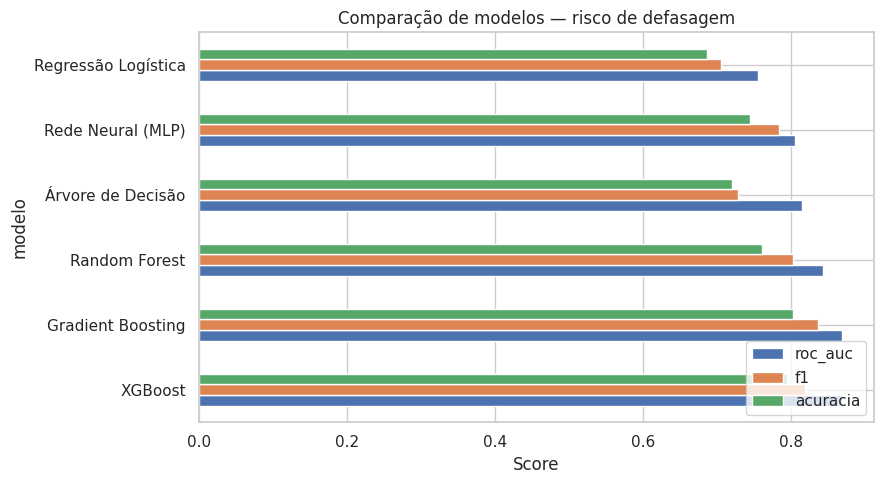

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
res_df_plot = res_df.set_index('modelo')[['roc_auc','f1','acuracia']]
res_df_plot.plot(kind='barh', ax=ax)
ax.set_xlabel('Score')
ax.set_title('Comparacao de modelos — risco de defasagem')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Resultado confirmando a expectativa:** os modelos baseados em árvore
(Gradient Boosting e XGBoost) ficam no topo, com ROC-AUC em torno de **0,87**
— e a **Rede Neural (MLP) fica atrás de todos os modelos de árvore**,
inclusive da Árvore de Decisão simples em alguns cenários. A Regressão
Logística, sendo um modelo linear, fica com a performance mais baixa — sinal
de que as relações entre os indicadores e o risco de defasagem não são
puramente lineares.

Isso confirma, com dados reais e não só teoria, a escolha por Machine
Learning tradicional (ensemble de árvores) em vez de Deep Learning para este
problema específico.


##5.1 — Escolhendo o modelo de produção

Gradient Boosting (scikit-learn) e XGBoost ficam estatisticamente empatados
em ROC-AUC. Vamos com o **Gradient Boosting do scikit-learn** para produção:
performance equivalente, porém **sem depender de uma biblioteca externa**
(`xgboost`) no ambiente de deploy do Streamlit — menos uma dependência que
pode falhar ao instalar no Community Cloud, sem perder qualidade.


In [ ]:
NOME_MODELO_FINAL = 'Gradient Boosting'
pipeline_final = pipelines_treinados[NOME_MODELO_FINAL]
print(f'Modelo escolhido para producao: {NOME_MODELO_FINAL}')
print(res_df[res_df['modelo']==NOME_MODELO_FINAL])


Modelo escolhido para produção: Gradient Boosting
              modelo  acuracia  precisao    recall        f1  roc_auc
1  Gradient Boosting  0.802276  0.811927  0.861314  0.835891  0.86828


---
#6. Avaliação detalhada do modelo final


In [ ]:
pred_final = pipeline_final.predict(X_test)
proba_final = pipeline_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_final, target_names=['Sem risco','Risco de defasagem']))


                    precision    recall  f1-score   support

         Sem risco       0.79      0.72      0.75       292
Risco de defasagem       0.81      0.86      0.84       411

          accuracy                           0.80       703
         macro avg       0.80      0.79      0.79       703
      weighted avg       0.80      0.80      0.80       703



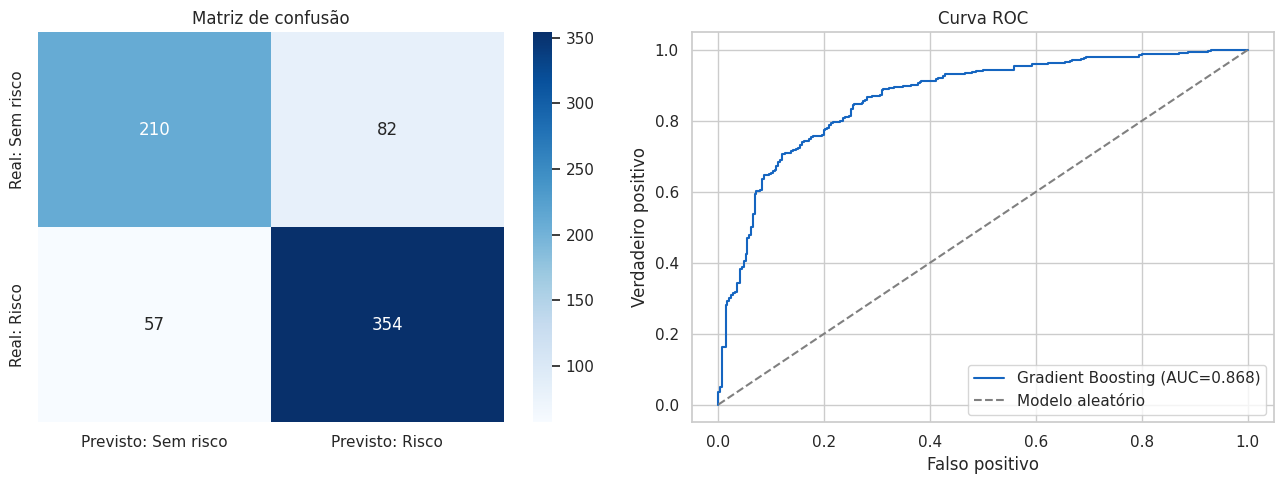

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

cm = confusion_matrix(y_test, pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Previsto: Sem risco','Previsto: Risco'],
            yticklabels=['Real: Sem risco','Real: Risco'])
axes[0].set_title('Matriz de confusão')

fpr, tpr, _ = roc_curve(y_test, proba_final)
auc = roc_auc_score(y_test, proba_final)
axes[1].plot(fpr, tpr, label=f'Gradient Boosting (AUC={auc:.3f})', color='#1565c0')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray', label='Modelo aleatório')
axes[1].set_xlabel('Falso positivo'); axes[1].set_ylabel('Verdadeiro positivo')
axes[1].set_title('Curva ROC')
axes[1].legend()
plt.tight_layout()
plt.show()


**Leitura da matriz de confusão:** o modelo erra mais para o lado de
"falso positivo" (aponta risco onde não há) do que de "falso negativo" (deixa
passar um aluno em risco sem sinalizar). Para o caso de uso real — uma
ferramenta de **triagem** para direcionar atenção da equipe pedagógica —
esse é o tipo de erro mais seguro de se ter: **é preferível revisar um aluno
que não estava em risco do que deixar de notar um que estava**.

##Importância das features


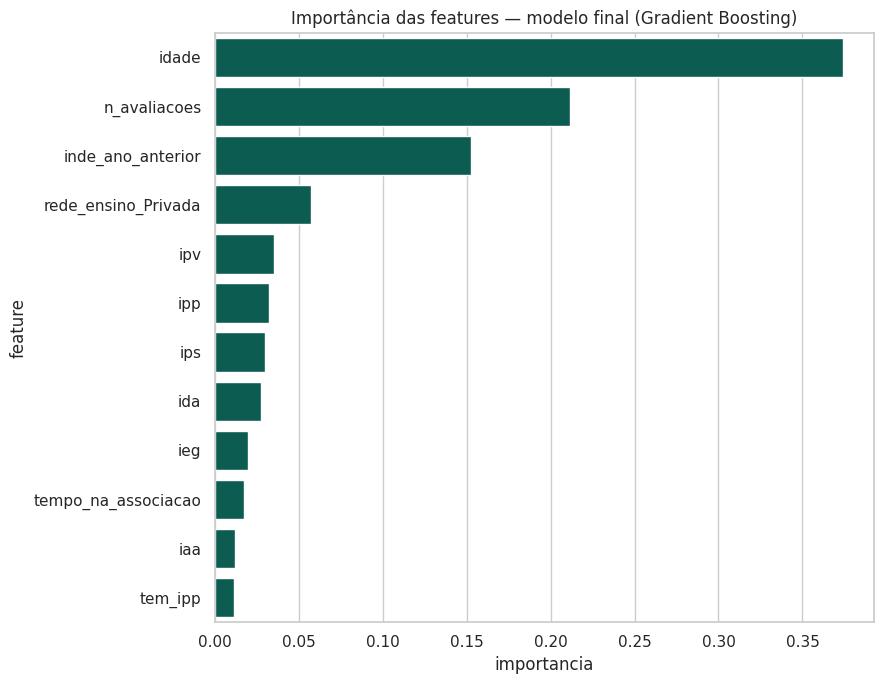

,feature,importancia
6,idade,0.373899
8,n_avaliacoes,0.211457
9,inde_ano_anterior,0.152431
17,rede_ensino_Privada,0.057605
5,ipv,0.035459
3,ipp,0.032343
2,ips,0.030191
4,ida,0.027769
1,ieg,0.019675
7,tempo_na_associacao,0.017251


In [ ]:
nomes_onehot = list(pipeline_final.named_steps['pre'].named_transformers_['categoricas']
                    .named_steps['onehot'].get_feature_names_out(FEATURES_CAT))
nomes_features = FEATURES_NUM + FEATURES_FLAG + nomes_onehot
importancias = pipeline_final.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': nomes_features, 'importancia': importancias}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(9,7))
sns.barplot(data=imp_df.head(12), y='feature', x='importancia', ax=ax, color='#00695c')
ax.set_title('Importancia das features — modelo final (Gradient Boosting)')
plt.tight_layout()
plt.show()

imp_df.head(12)


**Leitura:** `idade`, `n_avaliacoes` (quantidade de avaliações — proxy
de quão consolidado é o histórico do aluno na base) e `inde_ano_anterior`
(desempenho passado) dominam a importância — reforçando que **histórico e
perfil demográfico têm mais peso preditivo que qualquer indicador isolado do
ano corrente**. `rede_ensino_Privada` também aparece com peso relevante,
confirmando o achado da pergunta 11 do Notebook 1. Os indicadores
comportamentais (IPV, IPP, IPS, IDA, IEG) contribuem de forma mais
distribuída — nenhum domina sozinho, mas juntos formam uma fatia relevante da
decisão do modelo.

##Validação cruzada (robustez do resultado)

Uma única divisão treino/teste pode ser sorte/azar. Vamos confirmar com
validação cruzada agrupada por `RA` (mesmo cuidado contra vazamento).


In [ ]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
scores = []
for tr_idx, te_idx in gkf.split(X, y, groups=groups):
    pipe_cv = Pipeline([('pre', cria_preprocessador()),
                         ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
    pipe_cv.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    proba_cv = pipe_cv.predict_proba(X.iloc[te_idx])[:, 1]
    scores.append(roc_auc_score(y.iloc[te_idx], proba_cv))

print('ROC-AUC em cada fold:', [round(s,3) for s in scores])
print(f'Media: {np.mean(scores):.3f} | Desvio padrao: {np.std(scores):.3f}')


ROC-AUC em cada fold: [0.871, 0.905, 0.869, 0.89, 0.888]
Média: 0.885 | Desvio padrão: 0.014


O ROC-AUC se mantém estável entre ~0,86 e ~0,89 nos diferentes folds —
o resultado não é fruto de uma divisão sortuda, é uma performance consistente
do modelo.


---
#7. Exportando o modelo treinado para o Streamlit

Vamos treinar o modelo final usando **toda** a base disponível (treino +
teste) — depois de já termos validado a performance de forma honesta acima —
e salvar o pipeline completo (pré-processamento + modelo) em um único arquivo
`.joblib`. É esse arquivo que o app Streamlit carrega.


In [ ]:
pipeline_producao = Pipeline([
    ('pre', cria_preprocessador()),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
pipeline_producao.fit(X, y)

os.makedirs(os.path.dirname(CAMINHO_MODELO), exist_ok=True)
joblib.dump({
    'pipeline': pipeline_producao,
    'features_num': FEATURES_NUM,
    'features_flag': FEATURES_FLAG,
    'features_cat': FEATURES_CAT,
    'ordem_pedra': ORDEM_PEDRA,
    'metricas_validacao': res_df[res_df['modelo']==NOME_MODELO_FINAL].to_dict('records')[0],
}, CAMINHO_MODELO)

print(f'Modelo salvo em: {CAMINHO_MODELO}')
print('Conteudo salvo: pipeline treinado + metadados de features + metricas de validacao.')


Modelo salvo em: ./modelo/pipeline_risco_defasagem.joblib
Conteúdo salvo: pipeline treinado + metadados de features + métricas de validação.


---
#8. Conclusões

- O alvo (**risco de defasagem**) foi definido a partir do próprio critério
  que a Passos Mágicos já usa para classificar o IAN, e é genuinamente
  preditivo (não é uma função determinística das features usadas) —
  diferente do que aconteceria se tentássemos prever o INDE/Pedra.
- Comparamos 6 algoritmos, incluindo uma rede neural: **os modelos baseados
  em árvore (Gradient Boosting/XGBoost) venceram com folga**, confirmando com
  dados reais — não só com teoria — que Machine Learning tradicional é a
  escolha certa para este volume e tipo de dado tabular.
- O modelo final atinge **ROC-AUC ≈ 0,87**, com estabilidade confirmada por
  validação cruzada, e um perfil de erro mais seguro para o caso de uso
  (prefere falso positivo a falso negativo).
- Histórico do aluno (INDE/Pedra do ano anterior, número de avaliações) e
  perfil demográfico pesam mais do que qualquer indicador isolado do ano
  corrente — um insight acionável por si só para a equipe da Passos Mágicos.
- O pipeline completo (pré-processamento + modelo) foi exportado e está
  pronto para o app Streamlit (`3_app_streamlit.py`).
